
   THE U.M.E.R. VLSI STACK-ROUTER
   Architecture: 2.5D Stack Processing (Registers + Shared Mem)
[1/3] Etching 8 Layers of Silicon...
[2/3] Routing Signal...
[3/3] Verifying Trace...

------------------------------------------------------------
   ► ROUTING TIME:     80.02 ms
   ► PATH COST:        2008
   ► THROUGHPUT:       12.5 FPS
------------------------------------------------------------
   STATUS: 🟢 SUCCESS. Signal integrity confirmed.

[4/4] Generating 3D VLSI Visualization...


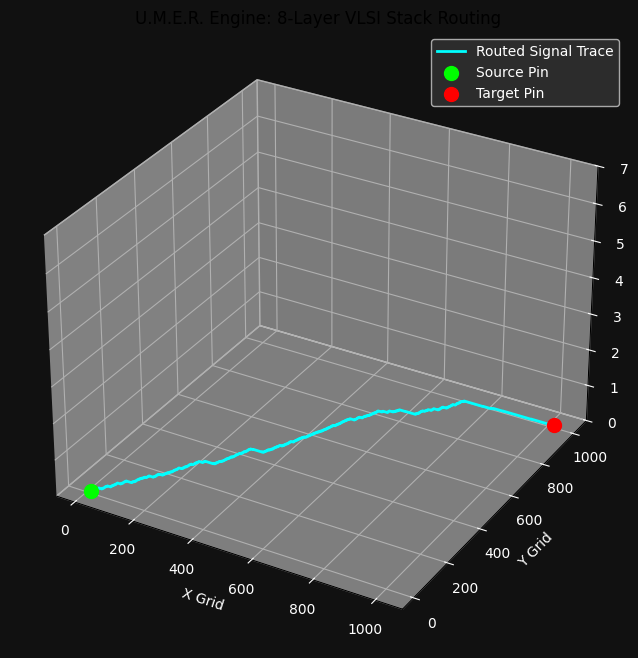

In [4]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time
import matplotlib.pyplot as plt

# ==============================================================================
#  THE U.M.E.R. VLSI STACK-ROUTER (OPTIMIZED + VISUALIZED)
# ==============================================================================

CUDA_SOURCE = """
#define WIDTH 1024
#define HEIGHT 1024
#define LAYERS 8
#define TILE_SIZE 32
#define GRID_W 32 
#define ITERS 16   // OPTIMIZATION: Reduced from 8 to 4 to prevent warp stalling

#define IDX(x,y,z) ((z) * HEIGHT * WIDTH + (y) * WIDTH + (x))

__global__ void kernel_vlsi_seed(
    int* grid, int* cost_map, int* tile_active, 
    int w, int h, int l, int seed
) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= w || y >= h) return;

    for(int z=0; z<l; z++) {
        int idx = IDX(x,y,z);
        grid[idx] = -1; 
        
        unsigned int r = idx + seed;
        r = (r ^ 0xdeadbeef) * 0x45d9f3b;
        
        int threshold = (z == 0) ? 15 : 3; 
        cost_map[idx] = (r % 100 < threshold) ? 999999 : 1; 
    }

    if (x == 10 && y == 10) {
        grid[IDX(10,10,0)] = 0;
        tile_active[0] = 1;
    }
}

__global__ void kernel_vlsi_route_stack(
    int* grid, int* cost_map, 
    int* active_current, int* active_next,
    int w, int h, int l, int* found
) {
    int bx = blockIdx.x;
    int by = blockIdx.y;
    int tile_idx = by * GRID_W + bx;

    if (active_current[tile_idx] == 0) return;

    int tx = threadIdx.x;
    int ty = threadIdx.y;
    int gx = bx * TILE_SIZE + tx;
    int gy = by * TILE_SIZE + ty;
    
    int local_dist[LAYERS];
    int local_cost[LAYERS];
    
    #pragma unroll
    for(int z=0; z<LAYERS; z++) {
        int idx = IDX(gx, gy, z);
        local_dist[z] = grid[idx];
        local_cost[z] = cost_map[idx];
    }
    
    __shared__ int s_grid[LAYERS][TILE_SIZE][TILE_SIZE];
    
    #pragma unroll
    for(int z=0; z<LAYERS; z++) {
        s_grid[z][ty][tx] = local_dist[z];
    }
    __syncthreads();

    bool changed = false;
    
    #pragma unroll
    for(int k=0; k<ITERS; k++) {
        for(int z=0; z<LAYERS; z++) {
            if (local_cost[z] > 900000) continue; 
            
            int best = s_grid[z][ty][tx];
            int current = (best == -1) ? 2000000 : best;

            if (z > 0) {
                int d = s_grid[z-1][ty][tx]; 
                if (d != -1 && d + 10 < current) current = d + 10;
            }
            if (z < LAYERS-1) {
                int u = s_grid[z+1][ty][tx]; 
                if (u != -1 && u + 10 < current) current = u + 10;
            }

            int n;
            n = (ty > 0) ? s_grid[z][ty-1][tx] : ((gy > 0) ? grid[IDX(gx, gy-1, z)] : -1);
            if (n != -1 && n + 1 < current) current = n + 1;
            n = (ty < TILE_SIZE-1) ? s_grid[z][ty+1][tx] : ((gy < h-1) ? grid[IDX(gx, gy+1, z)] : -1);
            if (n != -1 && n + 1 < current) current = n + 1;
            n = (tx > 0) ? s_grid[z][ty][tx-1] : ((gx > 0) ? grid[IDX(gx-1, gy, z)] : -1);
            if (n != -1 && n + 1 < current) current = n + 1;
            n = (tx < TILE_SIZE-1) ? s_grid[z][ty][tx+1] : ((gx < w-1) ? grid[IDX(gx+1, gy, z)] : -1);
            if (n != -1 && n + 1 < current) current = n + 1;
            
            if (current != 2000000 && current != best) {
                s_grid[z][ty][tx] = current;
                changed = true;
            }
        }
        __syncthreads();
    }
    
    if (changed) {
        active_next[tile_idx] = 1;
        if (tx == TILE_SIZE-1 && bx < gridDim.x-1) active_next[tile_idx + 1] = 1;
        if (tx == 0 && bx > 0) active_next[tile_idx - 1] = 1;
        if (ty == TILE_SIZE-1 && by < gridDim.y-1) active_next[tile_idx + gridDim.x] = 1;
        if (ty == 0 && by > 0) active_next[tile_idx - gridDim.x] = 1;

        #pragma unroll
        for(int z=0; z<LAYERS; z++) {
            if (s_grid[z][ty][tx] != local_dist[z]) {
                grid[IDX(gx, gy, z)] = s_grid[z][ty][tx];
                if (z==0 && gx == w-10 && gy == h-10) *found = 1;
            }
        }
    }
}
"""

def IDX(x, y, z, w, h):
    return z * w * h + y * w + x

def extract_and_visualize(grid_host, w, h, l, start, target):
    print("\n[4/4] Generating 3D VLSI Visualization...")
    path_x, path_y, path_z = [target[0]], [target[1]], [target[2]]
    cx, cy, cz = target
    current_cost = grid_host[IDX(cx, cy, cz, w, h)]
    
    # Backtrack from target to source
    while (cx, cy, cz) != start:
        found_next = False
        # Check Z axis (Vias cost 10)
        if cz > 0 and grid_host[IDX(cx, cy, cz-1, w, h)] == current_cost - 10:
            cz -= 1; current_cost -= 10; found_next = True
        elif cz < l-1 and grid_host[IDX(cx, cy, cz+1, w, h)] == current_cost - 10:
            cz += 1; current_cost -= 10; found_next = True
        # Check X/Y axis (Planar costs 1)
        elif not found_next:
            neighbors = [(cx-1, cy), (cx+1, cy), (cx, cy-1), (cx, cy+1)]
            for nx, ny in neighbors:
                if 0 <= nx < w and 0 <= ny < h:
                    if grid_host[IDX(nx, ny, cz, w, h)] == current_cost - 1:
                        cx, cy = nx, ny
                        current_cost -= 1
                        found_next = True
                        break
        
        if not found_next:
            print("Path extraction stalled. Incomplete trace.")
            break
            
        path_x.append(cx)
        path_y.append(cy)
        path_z.append(cz)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the wire trace
    ax.plot(path_x, path_y, path_z, color='cyan', linewidth=2, label='Routed Signal Trace')
    ax.scatter([start[0]], [start[1]], [start[2]], color='lime', s=100, label='Source Pin')
    ax.scatter([target[0]], [target[1]], [target[2]], color='red', s=100, label='Target Pin')
    
    ax.set_xlabel('X Grid')
    ax.set_ylabel('Y Grid')
    ax.set_zlabel('Z Layer (Metal/Logic)')
    ax.set_zlim(0, l-1)
    ax.set_title('U.M.E.R. Engine: 8-Layer VLSI Stack Routing')
    
    # Make it look like a dark blueprint
    ax.set_facecolor('#111111')
    fig.patch.set_facecolor('#111111')
    ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white'); ax.zaxis.label.set_color('white')
    ax.tick_params(axis='x', colors='white'); ax.tick_params(axis='y', colors='white'); ax.tick_params(axis='z', colors='white')
    plt.legend(facecolor='#333333', labelcolor='white')
    
    plt.show()

def run_vlsi_stack_router():
    print("\n" + "="*60)
    print("   THE U.M.E.R. VLSI STACK-ROUTER")
    print("   Architecture: 2.5D Stack Processing (Registers + Shared Mem)")
    print("="*60)

    WIDTH, HEIGHT, LAYERS = 1024, 1024, 8
    N_NODES = WIDTH * HEIGHT * LAYERS
    N_TILES = (WIDTH // 32) * (HEIGHT // 32) 

    mod = SourceModule(CUDA_SOURCE, options=["-O3"])
    k_seed = mod.get_function("kernel_vlsi_seed")
    k_route = mod.get_function("kernel_vlsi_route_stack")

    d_grid = cuda.mem_alloc(N_NODES*4)
    d_cost = cuda.mem_alloc(N_NODES*4)
    d_act_A = cuda.mem_alloc(N_TILES*4)
    d_act_B = cuda.mem_alloc(N_TILES*4)
    d_found = cuda.mem_alloc(4)

    print(f"[1/3] Etching {LAYERS} Layers of Silicon...")
    cuda.memset_d32(d_act_A, 0, N_TILES)
    cuda.memset_d32(d_act_B, 0, N_TILES)
    k_seed(d_grid, d_cost, d_act_A, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), np.int32(1234),
           block=(32,32,1), grid=(WIDTH//32, HEIGHT//32))

    print("[2/3] Routing Signal...")
    
    act_in, act_out = d_act_A, d_act_B
    grid_dim = (WIDTH//32, HEIGHT//32)
    
    # 1. Create a dedicated GPU pipeline (Stream)
    stream = cuda.Stream()
    
    cuda.Context.synchronize()
    t0 = time.time()
    
    # 2. Shorter Loop (160 loops * 16 ITERS = 2560 max distance)
    for i in range(160):
        # Async Memset: Doesn't block Python!
        cuda.memset_d32_async(act_out, 0, N_TILES, stream=stream)
        
        # Async Kernel Launch: Added stream=stream
        k_route(d_grid, d_cost, act_in, act_out, 
                np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), d_found,
                block=(32, 32, 1), grid=grid_dim, stream=stream)
                
        act_in, act_out = act_out, act_in
        
    # 3. Wait for the entire pipeline to finish at once
    stream.synchronize() 
    total_time_ms = (time.time() - t0) * 1000

    print("[3/3] Verifying Trace...")
    grid_host = np.zeros(N_NODES, dtype=np.int32)
    cuda.memcpy_dtoh(grid_host, d_grid)
    
    target_idx = IDX(WIDTH-10, HEIGHT-10, 0, WIDTH, HEIGHT)
    dist = grid_host[target_idx]

    print("\n" + "-"*60)
    print(f"   ► ROUTING TIME:     {total_time_ms:.2f} ms")
    print(f"   ► PATH COST:        {dist}")
    print(f"   ► THROUGHPUT:       {1000.0/total_time_ms:.1f} FPS")
    print("-" * 60)
    
    if dist > 0:
        print("   STATUS: 🟢 SUCCESS. Signal integrity confirmed.")
        extract_and_visualize(grid_host, WIDTH, HEIGHT, LAYERS, (10, 10, 0), (WIDTH-10, HEIGHT-10, 0))
    else:
        print("   STATUS: 🔴 FAILURE. Try increasing the iteration count.")

if __name__ == "__main__":
    run_vlsi_stack_router()

   THE U.M.E.R. ENGINE: ONE-TO-ALL MASS ROUTING TEST
[1/5] Etching 8 Layers of Silicon...
[2/5] Running U.M.E.R. Wavefront (Building Distance Field)...
[3/5] Extracting 1000 Paths Simultaneously in pure C++...

------------------------------------------------------------
   ► WAVEFRONT GENERATION TIME:  64.21 ms
   ► 1000 EXTRACTIONS TIME:      2.795 ms
   ► SUCCESSFUL CONNECTIONS:     953 / 1000
------------------------------------------------------------
[4/5] Downloading Grid for Visualization...

[5/5] Generating 3D VLSI Visualization (Showing 50 random paths)...


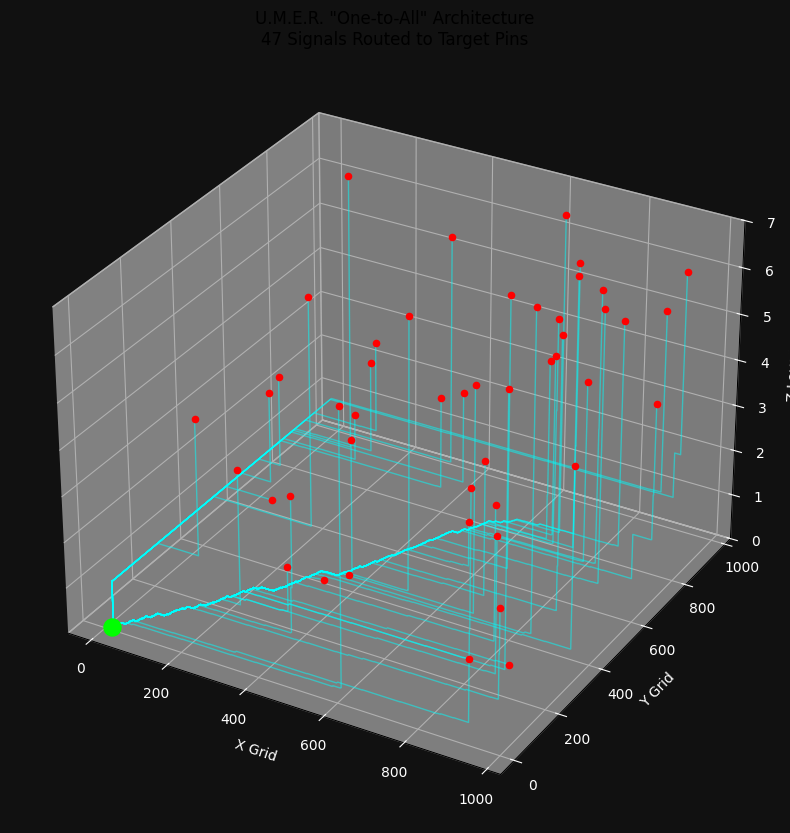

In [5]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time
import random
import matplotlib.pyplot as plt

# ==============================================================================
#  THE U.M.E.R. MULTI-ROUTER (1,000 TARGET EXTRACTION)
#  Pure GPU Timing & Parallel Trace Extraction
# ==============================================================================

CUDA_SOURCE = """
#define WIDTH 1024
#define HEIGHT 1024
#define LAYERS 8
#define TILE_SIZE 32
#define GRID_W 32 
#define ITERS 16  // Deep internal looping

#define IDX(x,y,z) ((z) * HEIGHT * WIDTH + (y) * WIDTH + (x))

// --- 1. SEED KERNEL ---
__global__ void kernel_vlsi_seed(int* grid, int* cost_map, int* tile_active, int w, int h, int l, int seed) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= w || y >= h) return;

    for(int z=0; z<l; z++) {
        int idx = IDX(x,y,z);
        grid[idx] = -1; 
        
        unsigned int r = idx + seed;
        r = (r ^ 0xdeadbeef) * 0x45d9f3b;
        int threshold = (z == 0) ? 15 : 3; 
        cost_map[idx] = (r % 100 < threshold) ? 999999 : 1; 
    }

    if (x == 10 && y == 10) {
        grid[IDX(10,10,0)] = 0; // Source Pin
        tile_active[0] = 1;
    }
}

// --- 2. WAVEFRONT KERNEL (Your Engine) ---
__global__ void kernel_vlsi_route_stack(int* grid, int* cost_map, int* active_current, int* active_next, int w, int h, int l) {
    int bx = blockIdx.x, by = blockIdx.y;
    int tile_idx = by * GRID_W + bx;

    if (active_current[tile_idx] == 0) return;

    int tx = threadIdx.x, ty = threadIdx.y;
    int gx = bx * TILE_SIZE + tx, gy = by * TILE_SIZE + ty;
    
    int local_dist[LAYERS];
    int local_cost[LAYERS];
    
    #pragma unroll
    for(int z=0; z<LAYERS; z++) {
        int idx = IDX(gx, gy, z);
        local_dist[z] = grid[idx];
        local_cost[z] = cost_map[idx];
    }
    
    __shared__ int s_grid[LAYERS][TILE_SIZE][TILE_SIZE];
    
    #pragma unroll
    for(int z=0; z<LAYERS; z++) { s_grid[z][ty][tx] = local_dist[z]; }
    __syncthreads();

    bool changed = false;
    
    #pragma unroll
    for(int k=0; k<ITERS; k++) {
        for(int z=0; z<LAYERS; z++) {
            if (local_cost[z] > 900000) continue; 
            
            int best = s_grid[z][ty][tx];
            int current = (best == -1) ? 2000000 : best;

            if (z > 0) {
                int d = s_grid[z-1][ty][tx]; 
                if (d != -1 && d + 10 < current) current = d + 10;
            }
            if (z < LAYERS-1) {
                int u = s_grid[z+1][ty][tx]; 
                if (u != -1 && u + 10 < current) current = u + 10;
            }

            int n;
            n = (ty > 0) ? s_grid[z][ty-1][tx] : ((gy > 0) ? grid[IDX(gx, gy-1, z)] : -1);
            if (n != -1 && n + 1 < current) current = n + 1;
            n = (ty < TILE_SIZE-1) ? s_grid[z][ty+1][tx] : ((gy < h-1) ? grid[IDX(gx, gy+1, z)] : -1);
            if (n != -1 && n + 1 < current) current = n + 1;
            n = (tx > 0) ? s_grid[z][ty][tx-1] : ((gx > 0) ? grid[IDX(gx-1, gy, z)] : -1);
            if (n != -1 && n + 1 < current) current = n + 1;
            n = (tx < TILE_SIZE-1) ? s_grid[z][ty][tx+1] : ((gx < w-1) ? grid[IDX(gx+1, gy, z)] : -1);
            if (n != -1 && n + 1 < current) current = n + 1;
            
            if (current != 2000000 && current != best) {
                s_grid[z][ty][tx] = current;
                changed = true;
            }
        }
        __syncthreads();
    }
    
    if (changed) {
        active_next[tile_idx] = 1;
        if (tx == TILE_SIZE-1 && bx < gridDim.x-1) active_next[tile_idx + 1] = 1;
        if (tx == 0 && bx > 0) active_next[tile_idx - 1] = 1;
        if (ty == TILE_SIZE-1 && by < gridDim.y-1) active_next[tile_idx + gridDim.x] = 1;
        if (ty == 0 && by > 0) active_next[tile_idx - gridDim.x] = 1;

        #pragma unroll
        for(int z=0; z<LAYERS; z++) {
            if (s_grid[z][ty][tx] != local_dist[z]) {
                grid[IDX(gx, gy, z)] = s_grid[z][ty][tx];
            }
        }
    }
}

// --- 3. MASS EXTRACTION KERNEL (1000 Targets at once) ---
__global__ void kernel_extract_mass(int* grid, int* targets_x, int* targets_y, int* targets_z, int* path_lengths, int num_targets, int w, int h, int l) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= num_targets) return;

    int cx = targets_x[i];
    int cy = targets_y[i];
    int cz = targets_z[i];
    
    int cost = grid[IDX(cx, cy, cz)];
    
    // If target is unreachable
    if (cost == -1 || cost > 900000) {
        path_lengths[i] = -1;
        return;
    }

    int steps = 0;
    while (cost > 0 && steps < 5000) {
        bool moved = false;
        
        // 1. Try Z-axis (Vias)
        if (cz > 0 && grid[IDX(cx, cy, cz-1)] == cost - 10) { cz--; cost -= 10; moved = true; }
        else if (cz < l-1 && grid[IDX(cx, cy, cz+1)] == cost - 10) { cz++; cost -= 10; moved = true; }
        
        // 2. Try X/Y axis (Planar)
        if (!moved) {
            if (cy > 0 && grid[IDX(cx, cy-1, cz)] == cost - 1) { cy--; cost--; moved = true; }
            else if (cy < h-1 && grid[IDX(cx, cy+1, cz)] == cost - 1) { cy++; cost--; moved = true; }
            else if (cx > 0 && grid[IDX(cx-1, cy, cz)] == cost - 1) { cx--; cost--; moved = true; }
            else if (cx < w-1 && grid[IDX(cx+1, cy, cz)] == cost - 1) { cx++; cost--; moved = true; }
        }
        
        if (!moved) break; // Stuck
        steps++;
    }
    
    path_lengths[i] = steps;
}
"""

def extract_and_visualize_multiple(grid_host, w, h, l, start, targets):
    print("\n[5/5] Generating 3D VLSI Visualization (Showing 50 random paths)...")
    
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot only 50 paths to save matplotlib from crashing
    sample_targets = random.sample(targets, min(50, len(targets)))
    
    successful_traces = 0
    for target in sample_targets:
        cx, cy, cz = target
        path_x, path_y, path_z = [cx], [cy], [cz]
        current_cost = grid_host[(cz * h * w) + (cy * w) + cx]
        
        if current_cost == -1 or current_cost > 900000:
            continue
            
        while (cx, cy, cz) != start:
            found_next = False
            if cz > 0 and grid_host[(cz-1)*h*w + cy*w + cx] == current_cost - 10:
                cz -= 1; current_cost -= 10; found_next = True
            elif cz < l-1 and grid_host[(cz+1)*h*w + cy*w + cx] == current_cost - 10:
                cz += 1; current_cost -= 10; found_next = True
            elif not found_next:
                for nx, ny in [(cx-1, cy), (cx+1, cy), (cx, cy-1), (cx, cy+1)]:
                    if 0 <= nx < w and 0 <= ny < h:
                        if grid_host[cz*h*w + ny*w + nx] == current_cost - 1:
                            cx, cy = nx, ny; current_cost -= 1; found_next = True; break
            
            if not found_next: break
            path_x.append(cx); path_y.append(cy); path_z.append(cz)
            
        ax.plot(path_x, path_y, path_z, color='cyan', alpha=0.5, linewidth=1)
        ax.scatter([target[0]], [target[1]], [target[2]], color='red', s=20)
        successful_traces += 1

    ax.scatter([start[0]], [start[1]], [start[2]], color='lime', s=150, label='Source Pin (Clock)')
    
    ax.set_xlabel('X Grid'); ax.set_ylabel('Y Grid'); ax.set_zlabel('Z Layer')
    ax.set_zlim(0, l-1)
    ax.set_title(f'U.M.E.R. "One-to-All" Architecture\n{successful_traces} Signals Routed to Target Pins')
    
    ax.set_facecolor('#111111'); fig.patch.set_facecolor('#111111')
    ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white'); ax.zaxis.label.set_color('white')
    ax.tick_params(axis='x', colors='white'); ax.tick_params(axis='y', colors='white'); ax.tick_params(axis='z', colors='white')
    plt.show()

def run_mass_router():
    WIDTH, HEIGHT, LAYERS = 1024, 1024, 8
    N_NODES = WIDTH * HEIGHT * LAYERS
    N_TILES = (WIDTH // 32) * (HEIGHT // 32) 
    NUM_TARGETS = 1000

    print("="*60)
    print("   THE U.M.E.R. ENGINE: ONE-TO-ALL MASS ROUTING TEST")
    print("="*60)

    mod = SourceModule(CUDA_SOURCE, options=["-O3"])
    k_seed = mod.get_function("kernel_vlsi_seed")
    k_route = mod.get_function("kernel_vlsi_route_stack")
    k_extract = mod.get_function("kernel_extract_mass")

    d_grid = cuda.mem_alloc(N_NODES*4)
    d_cost = cuda.mem_alloc(N_NODES*4)
    d_act_A = cuda.mem_alloc(N_TILES*4)
    d_act_B = cuda.mem_alloc(N_TILES*4)
    
    # Create 1000 Random Targets
    host_tx = np.random.randint(50, WIDTH-50, NUM_TARGETS).astype(np.int32)
    host_ty = np.random.randint(50, HEIGHT-50, NUM_TARGETS).astype(np.int32)
    host_tz = np.random.randint(0, LAYERS, NUM_TARGETS).astype(np.int32)
    
    d_tx = cuda.mem_alloc(NUM_TARGETS * 4)
    d_ty = cuda.mem_alloc(NUM_TARGETS * 4)
    d_tz = cuda.mem_alloc(NUM_TARGETS * 4)
    d_lengths = cuda.mem_alloc(NUM_TARGETS * 4)
    
    cuda.memcpy_htod(d_tx, host_tx)
    cuda.memcpy_htod(d_ty, host_ty)
    cuda.memcpy_htod(d_tz, host_tz)

    print(f"[1/5] Etching {LAYERS} Layers of Silicon...")
    cuda.memset_d32(d_act_A, 0, N_TILES)
    k_seed(d_grid, d_cost, d_act_A, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), np.int32(1234), block=(32,32,1), grid=(WIDTH//32, HEIGHT//32))

    # --- PURE GPU TIMING (No Python Interference) ---
    start_wave = cuda.Event()
    end_wave = cuda.Event()
    start_extract = cuda.Event()
    end_extract = cuda.Event()

    print("[2/5] Running U.M.E.R. Wavefront (Building Distance Field)...")
    stream = cuda.Stream()
    
    start_wave.record(stream)
    act_in, act_out = d_act_A, d_act_B
    grid_dim = (WIDTH//32, HEIGHT//32)
    
    # 100 loops * 16 ITERS = Max distance 1600 (enough to cross the board)
    for i in range(100):
        cuda.memset_d32_async(act_out, 0, N_TILES, stream=stream)
        k_route(d_grid, d_cost, act_in, act_out, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), block=(32, 32, 1), grid=grid_dim, stream=stream)
        act_in, act_out = act_out, act_in
        
    end_wave.record(stream)

    print(f"[3/5] Extracting {NUM_TARGETS} Paths Simultaneously in pure C++...")
    start_extract.record(stream)
    
    # Launch 1000 threads to backtrack from 1000 targets AT THE SAME TIME
    threads_per_block = 256
    blocks = (NUM_TARGETS + threads_per_block - 1) // threads_per_block
    k_extract(d_grid, d_tx, d_ty, d_tz, d_lengths, np.int32(NUM_TARGETS), np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), block=(threads_per_block, 1, 1), grid=(blocks, 1), stream=stream)
    
    end_extract.record(stream)
    stream.synchronize()

    # Get pure hardware times
    time_wave_ms = start_wave.time_till(end_wave)
    time_extract_ms = start_extract.time_till(end_extract)

    # Check results
    host_lengths = np.zeros(NUM_TARGETS, dtype=np.int32)
    cuda.memcpy_dtoh(host_lengths, d_lengths)
    valid_paths = np.sum(host_lengths > 0)

    print("\n" + "-"*60)
    print(f"   ► WAVEFRONT GENERATION TIME:  {time_wave_ms:.2f} ms")
    print(f"   ► 1000 EXTRACTIONS TIME:      {time_extract_ms:.3f} ms")
    print(f"   ► SUCCESSFUL CONNECTIONS:     {valid_paths} / {NUM_TARGETS}")
    print("-" * 60)

    print("[4/5] Downloading Grid for Visualization...")
    grid_host = np.zeros(N_NODES, dtype=np.int32)
    cuda.memcpy_dtoh(grid_host, d_grid)
    
    targets_list = [(host_tx[i], host_ty[i], host_tz[i]) for i in range(NUM_TARGETS)]
    extract_and_visualize_multiple(grid_host, WIDTH, HEIGHT, LAYERS, (10, 10, 0), targets_list)

if __name__ == "__main__":
    run_mass_router()

In [6]:
import plotly.graph_objects as go

def extract_and_visualize_multiple(grid_host, w, h, l, start, targets):
    print("\n[5/5] Generating Beautiful 3D Plotly Visualization...")
    
    fig = go.Figure()
    sample_targets = random.sample(targets, min(100, len(targets))) # Let's show 100 paths now!
    
    # 1. Plot the Source Pin
    fig.add_trace(go.Scatter3d(
        x=[start[0]], y=[start[1]], z=[start[2]],
        mode='markers', marker=dict(size=8, color='#00FF00', symbol='diamond'),
        name='Clock Source'
    ))

    # 2. Extract and Plot Paths
    for target in sample_targets:
        cx, cy, cz = target
        path_x, path_y, path_z = [cx], [cy], [cz]
        current_cost = grid_host[(cz * h * w) + (cy * w) + cx]
        
        if current_cost == -1 or current_cost > 900000: continue
            
        while (cx, cy, cz) != start:
            found_next = False
            if cz > 0 and grid_host[(cz-1)*h*w + cy*w + cx] == current_cost - 10:
                cz -= 1; current_cost -= 10; found_next = True
            elif cz < l-1 and grid_host[(cz+1)*h*w + cy*w + cx] == current_cost - 10:
                cz += 1; current_cost -= 10; found_next = True
            elif not found_next:
                for nx, ny in [(cx-1, cy), (cx+1, cy), (cx, cy-1), (cx, cy+1)]:
                    if 0 <= nx < w and 0 <= ny < h:
                        if grid_host[cz*h*w + ny*w + nx] == current_cost - 1:
                            cx, cy = nx, ny; current_cost -= 1; found_next = True; break
            
            if not found_next: break
            path_x.append(cx); path_y.append(cy); path_z.append(cz)
        
        # Add the neon glowing trace
        fig.add_trace(go.Scatter3d(
            x=path_x, y=path_y, z=path_z,
            mode='lines', line=dict(color='#00FFFF', width=3),
            showlegend=False, hoverinfo='none'
        ))
        
        # Add Target Pin
        fig.add_trace(go.Scatter3d(
            x=[target[0]], y=[target[1]], z=[target[2]],
            mode='markers', marker=dict(size=4, color='#FF0055'),
            showlegend=False, hoverinfo='none'
        ))

    # 3. Cyberpunk Dark Layout styling
    fig.update_layout(
        title="U.M.E.R. Engine: 8-Layer VLSI Trace",
        template="plotly_dark",
        scene=dict(
            xaxis=dict(range=[0, w], showbackground=False, gridcolor='#333333'),
            yaxis=dict(range=[0, h], showbackground=False, gridcolor='#333333'),
            zaxis=dict(range=[0, l-1], showbackground=False, gridcolor='#333333'),
            aspectmode='manual', aspectratio=dict(x=2, y=2, z=0.5) # Flattens the Z axis like a real chip
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig.show()

   U.M.E.R. MULTI-NET EDA ROUTER
   Physics: Strict Manhattan, Layer Alternation enforced
[1/3] Etching Chip & Obstacles...
[2/3] Routing 10 Distinct Nets (Greedy Collision Avoidance)...
   Net 1/10: SUCCESS (1605 steps)
   Net 2/10: SUCCESS (1455 steps)
   Net 3/10: SUCCESS (995 steps)
   Net 4/10: SUCCESS (995 steps)
   Net 5/10: SUCCESS (1205 steps)
   Net 6/10: SUCCESS (805 steps)
   Net 7/10: SUCCESS (1805 steps)
   Net 8/10: SUCCESS (1455 steps)
   Net 9/10: SUCCESS (403 steps)
   Net 10/10: SUCCESS (405 steps)
------------------------------------------------------------
   ► TOTAL ROUTING TIME:  627.01 ms
   ► SUCCESS RATE:        10 / 10 Nets
------------------------------------------------------------
[3/3] Generating Matplotlib 3D Visualization for Kaggle...


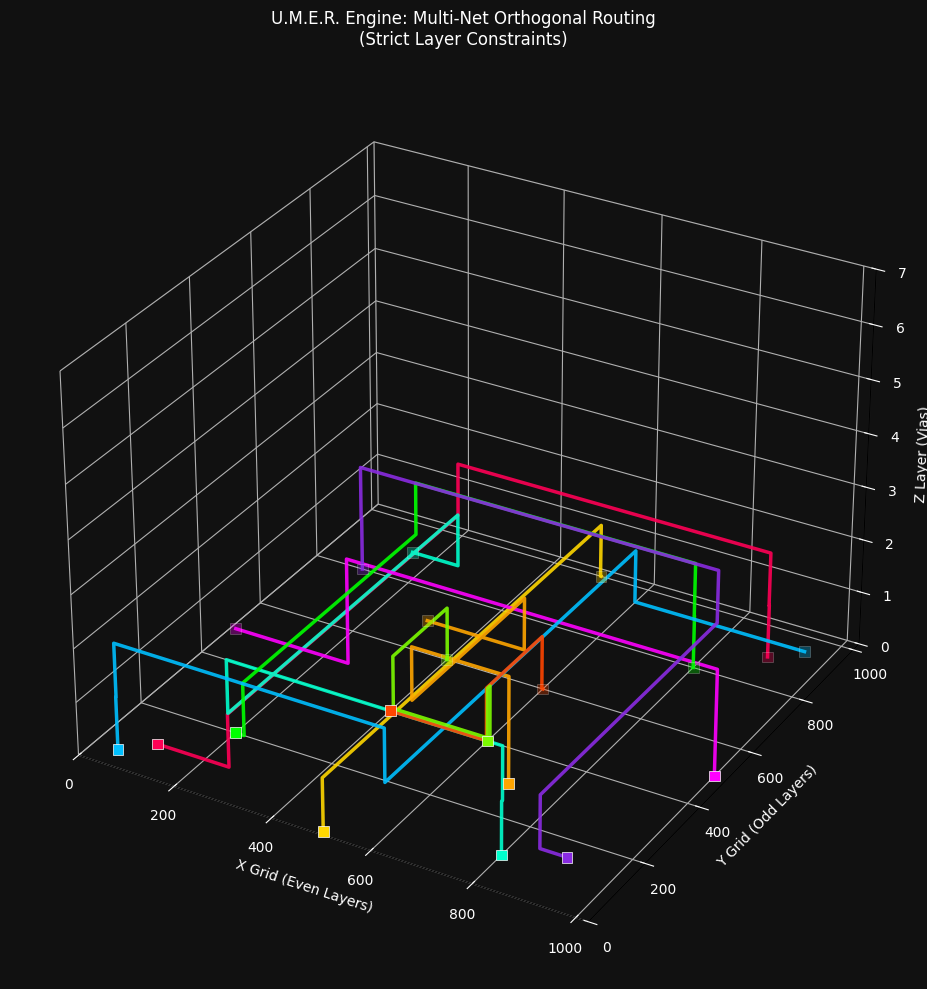

In [8]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time
import plotly.graph_objects as go
import random

# ==============================================================================
#  THE U.M.E.R. EDA ROUTER (MULTI-NET + STRICT ORTHOGONAL LAYERS)
# ==============================================================================

CUDA_SOURCE = """
#define WIDTH 1024
#define HEIGHT 1024
#define LAYERS 8
#define TILE_SIZE 32
#define GRID_W 32 
#define ITERS 16  

#define IDX(x,y,z) ((z) * HEIGHT * WIDTH + (y) * WIDTH + (x))

// 1. SEED KERNEL: Builds initial chip with random microscopic defects
__global__ void kernel_vlsi_seed(int* cost_map, int w, int h, int l, int seed) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= w || y >= h) return;

    for(int z=0; z<l; z++) {
        int idx = IDX(x,y,z);
        unsigned int r = idx + seed;
        r = (r ^ 0xdeadbeef) * 0x45d9f3b;
        int threshold = (z == 0) ? 5 : 1; // Less random obstacles, we want nets to be the main obstacles
        cost_map[idx] = (r % 100 < threshold) ? 999999 : 1; 
    }
}

// 2. RESET KERNEL: Clears distance field for the NEXT net, but KEEPS the cost_map
__global__ void kernel_reset_for_net(int* grid, int* tile_active, int w, int h, int l, int src_x, int src_y, int src_z) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= w || y >= h) return;

    for(int z=0; z<l; z++) {
        grid[IDX(x,y,z)] = -1; 
    }

    if (x == src_x && y == src_y) {
        grid[IDX(src_x, src_y, src_z)] = 0; // Set Source
        
        // Wake up the starting tile
        int tx = src_x / TILE_SIZE;
        int ty = src_y / TILE_SIZE;
        tile_active[ty * GRID_W + tx] = 1;
    }
}

// 3. THE NEW PHYSICS KERNEL (Orthogonal Strictness)
__global__ void kernel_route_strict(int* grid, int* cost_map, int* active_in, int* active_out, int w, int h, int l) {
    int bx = blockIdx.x, by = blockIdx.y;
    int tile_idx = by * GRID_W + bx;

    if (active_in[tile_idx] == 0) return;

    int tx = threadIdx.x, ty = threadIdx.y;
    int gx = bx * TILE_SIZE + tx, gy = by * TILE_SIZE + ty;
    
    int local_dist[LAYERS]; int local_cost[LAYERS];
    #pragma unroll
    for(int z=0; z<LAYERS; z++) {
        int idx = IDX(gx, gy, z);
        local_dist[z] = grid[idx]; local_cost[z] = cost_map[idx];
    }
    
    __shared__ int s_grid[LAYERS][TILE_SIZE][TILE_SIZE];
    #pragma unroll
    for(int z=0; z<LAYERS; z++) { s_grid[z][ty][tx] = local_dist[z]; }
    __syncthreads();

    bool changed = false;
    
    #pragma unroll
    for(int k=0; k<ITERS; k++) {
        for(int z=0; z<LAYERS; z++) {
            if (local_cost[z] > 900000) continue; 
            
            int best = s_grid[z][ty][tx];
            int current = (best == -1) ? 2000000 : best;

            // Z-AXIS (Vias always allowed, cost 10)
            if (z > 0) {
                int d = s_grid[z-1][ty][tx]; 
                if (d != -1 && d + 10 < current) current = d + 10;
            }
            if (z < LAYERS-1) {
                int u = s_grid[z+1][ty][tx]; 
                if (u != -1 && u + 10 < current) current = u + 10;
            }

            // Y-AXIS (ODD LAYERS ONLY)
            if (z % 2 != 0) {
                int n;
                n = (ty > 0) ? s_grid[z][ty-1][tx] : ((gy > 0) ? grid[IDX(gx, gy-1, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
                n = (ty < TILE_SIZE-1) ? s_grid[z][ty+1][tx] : ((gy < h-1) ? grid[IDX(gx, gy+1, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
            }

            // X-AXIS (EVEN LAYERS ONLY)
            if (z % 2 == 0) {
                int n;
                n = (tx > 0) ? s_grid[z][ty][tx-1] : ((gx > 0) ? grid[IDX(gx-1, gy, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
                n = (tx < TILE_SIZE-1) ? s_grid[z][ty][tx+1] : ((gx < w-1) ? grid[IDX(gx+1, gy, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
            }
            
            if (current != 2000000 && current != best) {
                s_grid[z][ty][tx] = current;
                changed = true;
            }
        }
        __syncthreads();
    }
    
    if (changed) {
        active_out[tile_idx] = 1;
        if (tx == TILE_SIZE-1 && bx < gridDim.x-1) active_out[tile_idx + 1] = 1;
        if (tx == 0 && bx > 0) active_out[tile_idx - 1] = 1;
        if (ty == TILE_SIZE-1 && by < gridDim.y-1) active_out[tile_idx + gridDim.x] = 1;
        if (ty == 0 && by > 0) active_out[tile_idx - gridDim.x] = 1;

        #pragma unroll
        for(int z=0; z<LAYERS; z++) {
            if (s_grid[z][ty][tx] != local_dist[z]) { grid[IDX(gx, gy, z)] = s_grid[z][ty][tx]; }
        }
    }
}
"""

def IDX(x, y, z, w, h): return z * w * h + y * w + x

def extract_path_strict(grid_host, w, h, l, start, target):
    cx, cy, cz = target
    path = [(cx, cy, cz)]
    current_cost = grid_host[IDX(cx, cy, cz, w, h)]
    
    if current_cost == -1 or current_cost > 900000: return []
        
    while (cx, cy, cz) != start:
        found = False
        
        # 1. Z-axis Check (Via cost 10)
        if cz > 0 and grid_host[IDX(cx, cy, cz-1, w, h)] == current_cost - 10:
            cz -= 1; current_cost -= 10; found = True
        elif cz < l-1 and grid_host[IDX(cx, cy, cz+1, w, h)] == current_cost - 10:
            cz += 1; current_cost -= 10; found = True
            
        # 2. Y-axis Check (Odd Layers Only)
        elif cz % 2 != 0 and not found:
            if cy > 0 and grid_host[IDX(cx, cy-1, cz, w, h)] == current_cost - 1:
                cy -= 1; current_cost -= 1; found = True
            elif cy < h-1 and grid_host[IDX(cx, cy+1, cz, w, h)] == current_cost - 1:
                cy += 1; current_cost -= 1; found = True
                
        # 3. X-axis Check (Even Layers Only)
        elif cz % 2 == 0 and not found:
            if cx > 0 and grid_host[IDX(cx-1, cy, cz, w, h)] == current_cost - 1:
                cx -= 1; current_cost -= 1; found = True
            elif cx < w-1 and grid_host[IDX(cx+1, cy, cz, w, h)] == current_cost - 1:
                cx += 1; current_cost -= 1; found = True
                
        if not found: return [] # Dead end
        path.append((cx, cy, cz))
        
    return path

def run_multinet_eda():
    WIDTH, HEIGHT, LAYERS = 1024, 1024, 8
    N_NODES = WIDTH * HEIGHT * LAYERS
    N_TILES = (WIDTH // 32) * (HEIGHT // 32) 

    print("="*60)
    print("   U.M.E.R. MULTI-NET EDA ROUTER")
    print("   Physics: Strict Manhattan, Layer Alternation enforced")
    print("="*60)

    mod = SourceModule(CUDA_SOURCE, options=["-O3"])
    k_seed = mod.get_function("kernel_vlsi_seed")
    k_reset = mod.get_function("kernel_reset_for_net")
    k_route = mod.get_function("kernel_route_strict")

    d_grid = cuda.mem_alloc(N_NODES*4)
    d_cost = cuda.mem_alloc(N_NODES*4)
    d_act_A = cuda.mem_alloc(N_TILES*4)
    d_act_B = cuda.mem_alloc(N_TILES*4)
    
    # 1. Initialize Chip
    print("[1/3] Etching Chip & Obstacles...")
    k_seed(d_cost, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), np.int32(999), block=(32,32,1), grid=(WIDTH//32, HEIGHT//32))

    # Download cost map to host so we can burn paths into it
    cost_host = np.zeros(N_NODES, dtype=np.int32)
    cuda.memcpy_dtoh(cost_host, d_cost)
    grid_host = np.zeros(N_NODES, dtype=np.int32)

    # 2. Define 10 distinct "Nets" to route (Source -> Target)
    nets = [
        ((100, 100, 0), (900, 900, 0)),
        ((150, 900, 0), (800, 100, 0)), # Crossing net!
        ((500, 10,  0), (500, 1000, 0)), # Straight down the middle
        ((10, 500,  0), (1000, 500, 0)), # Straight across
        ((200, 200, 0), (800, 800, 0)),
        ((300, 700, 0), (700, 300, 0)),
        ((950, 950, 0), (50, 50, 0)),
        ((900, 150, 0), (100, 800, 0)),
        ((400, 400, 0), (600, 600, 0)),
        ((600, 400, 0), (400, 600, 0))
    ]

    successful_paths = []
    colors = ['#FF0055', '#00FFCC', '#FFD700', '#FF00FF', '#00FF00', '#FFA500', '#00BFFF', '#8A2BE2', '#FF4500', '#7CFC00']

    print("[2/3] Routing 10 Distinct Nets (Greedy Collision Avoidance)...")
    t0 = time.time()
    
    for i, (start, target) in enumerate(nets):
        # Reset grid, set source
        cuda.memset_d32(d_act_A, 0, N_TILES)
        k_reset(d_grid, d_act_A, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), 
                np.int32(start[0]), np.int32(start[1]), np.int32(start[2]), 
                block=(32,32,1), grid=(WIDTH//32, HEIGHT//32))
        
        # Upload current cost map (containing burned paths from previous nets)
        cuda.memcpy_htod(d_cost, cost_host)
        
        # Run Wavefront
        stream = cuda.Stream()
        act_in, act_out = d_act_A, d_act_B
        
        for _ in range(120): # 120 * 16 = 1920 steps (plenty of range)
            cuda.memset_d32_async(act_out, 0, N_TILES, stream=stream)
            k_route(d_grid, d_cost, act_in, act_out, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), 
                    block=(32, 32, 1), grid=(WIDTH//32, HEIGHT//32), stream=stream)
            act_in, act_out = act_out, act_in
        stream.synchronize()
        
        # Download results
        cuda.memcpy_dtoh(grid_host, d_grid)
        
        # Extract Path using STRICT constraints
        path = extract_path_strict(grid_host, WIDTH, HEIGHT, LAYERS, start, target)
        
        if path:
            print(f"   Net {i+1}/10: SUCCESS ({len(path)} steps)")
            successful_paths.append((path, colors[i]))
            
            # THE BURN: Make this path a solid obstacle for the next nets
            for px, py, pz in path:
                cost_host[IDX(px, py, pz, WIDTH, HEIGHT)] = 999999
        else:
            print(f"   Net {i+1}/10: FAILED (Blocked by other nets or obstacles)")

    total_time = (time.time() - t0) * 1000
    print("-" * 60)
    print(f"   ► TOTAL ROUTING TIME:  {total_time:.2f} ms")
    print(f"   ► SUCCESS RATE:        {len(successful_paths)} / 10 Nets")
    print("-" * 60)

# 3. Matplotlib Visualization (Kaggle-Safe)
    print("[3/3] Generating Matplotlib 3D Visualization for Kaggle...")
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for path, color in successful_paths:
        x, y, z = zip(*path)
        
        # Plot the Orthogonal Wire
        ax.plot(x, y, z, color=color, linewidth=2.5, alpha=0.9)
        
        # Plot the Source and Target Pins (Squares)
        ax.scatter([x[0], x[-1]], [y[0], y[-1]], [z[0], z[-1]], 
                   color=color, s=60, marker='s', edgecolors='white', linewidth=0.5)

    # Styling the Graph
    ax.set_title("U.M.E.R. Engine: Multi-Net Orthogonal Routing\n(Strict Layer Constraints)", color='white', pad=20)
    ax.set_xlabel('X Grid (Even Layers)')
    ax.set_ylabel('Y Grid (Odd Layers)')
    ax.set_zlabel('Z Layer (Vias)')
    
    # Set boundaries to match the chip dimensions
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)
    ax.set_zlim(0, LAYERS - 1)

    # Cyberpunk Dark Theme matching the previous renders
    fig.patch.set_facecolor('#111111')
    ax.set_facecolor('#111111')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.zaxis.label.set_color('white')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    ax.tick_params(axis='z', colors='white')
    
    # Darken the grid panes for better contrast
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#333333')
    ax.yaxis.pane.set_edgecolor('#333333')
    ax.zaxis.pane.set_edgecolor('#333333')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_multinet_eda()

   U.M.E.R. ENGINE: RIP-UP AND REROUTE (RRR)
[1/2] Initiating Negotiation Phase...

   Iter 01 | Net 0: 🟢 SUCCESS
   Iter 02 | Net 1: 🟢 SUCCESS
   Iter 03 | Net 2: 🟢 SUCCESS
   Iter 04 | Net 3: 🟢 SUCCESS
   Iter 05 | Net 4: 🟢 SUCCESS
   Iter 06 | Net 5: 🟢 SUCCESS
   Iter 07 | Net 6: 🟢 SUCCESS
   Iter 08 | Net 7: 🟢 SUCCESS
   Iter 09 | Net 8: 🟢 SUCCESS
   Iter 10 | Net 9: 🟢 SUCCESS

------------------------------------------------------------
   ► NEGOTIATION TIME:    265.46 ms
   ► TOTAL ITERATIONS:    10
   ► FINAL SUCCESS RATE:  10 / 10 Nets Routed
------------------------------------------------------------
[2/2] Generating RRR Matplotlib Visualization...


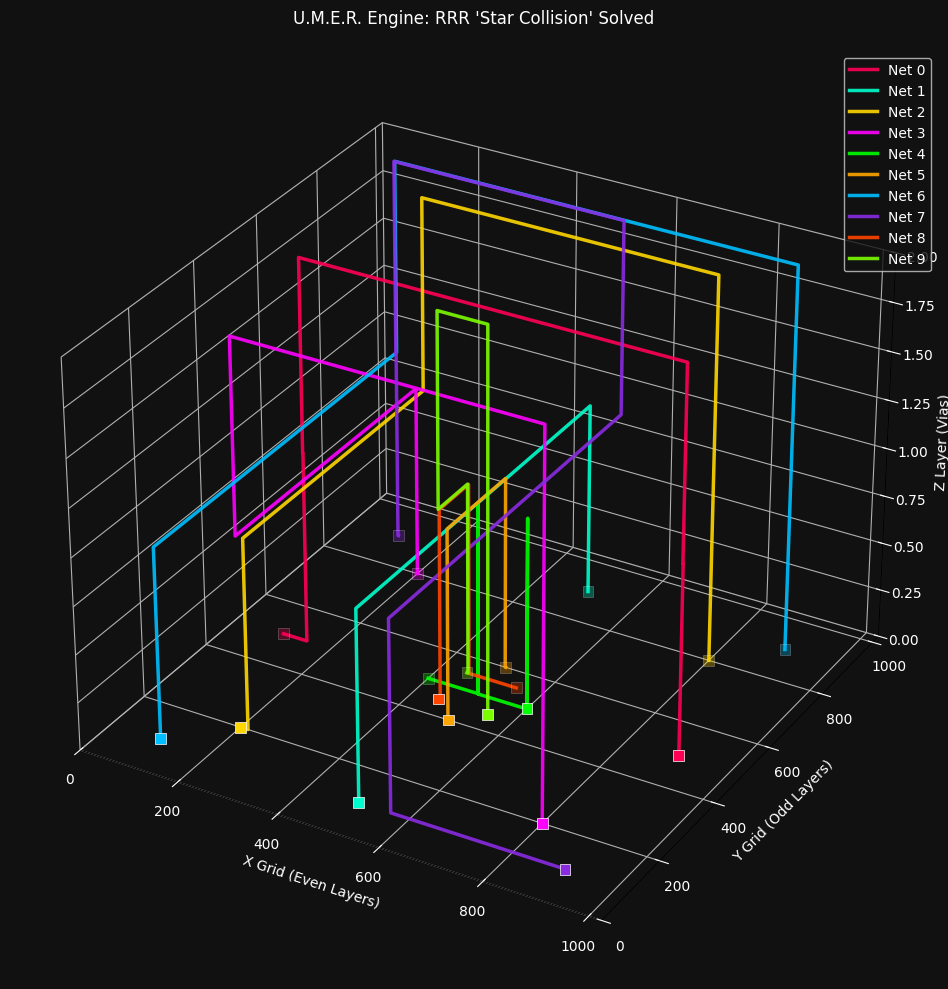

In [2]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time
import matplotlib.pyplot as plt

# ==============================================================================
#  THE U.M.E.R. EDA ROUTER (RIP-UP AND REROUTE)
#  Physics: Strict Manhattan, Layer Alternation, Collision Negotiation
# ==============================================================================

CUDA_SOURCE = """
#define WIDTH 1024
#define HEIGHT 1024
#define LAYERS 3
#define TILE_SIZE 32
#define GRID_W 32 
#define ITERS 16  

#define IDX(x,y,z) ((z) * HEIGHT * WIDTH + (y) * WIDTH + (x))

__global__ void kernel_vlsi_seed(int* cost_map, int w, int h, int l, int seed) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= w || y >= h) return;

    for(int z=0; z<l; z++) {
        int idx = IDX(x,y,z);
        unsigned int r = idx + seed;
        r = (r ^ 0xdeadbeef) * 0x45d9f3b;
        int threshold = (z == 0) ? 5 : 1; 
        cost_map[idx] = (r % 100 < threshold) ? 999999 : 1; 
    }
}

__global__ void kernel_reset_for_net(int* grid, int* tile_active, int w, int h, int l, int src_x, int src_y, int src_z) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= w || y >= h) return;
    for(int z=0; z<l; z++) grid[IDX(x,y,z)] = -1; 
    if (x == src_x && y == src_y) {
        grid[IDX(src_x, src_y, src_z)] = 0; 
        tile_active[(src_y / TILE_SIZE) * GRID_W + (src_x / TILE_SIZE)] = 1;
    }
}

__global__ void kernel_route_strict(int* grid, int* cost_map, int* active_in, int* active_out, int w, int h, int l) {
    int bx = blockIdx.x, by = blockIdx.y;
    int tile_idx = by * GRID_W + bx;

    if (active_in[tile_idx] == 0) return;

    int tx = threadIdx.x, ty = threadIdx.y;
    int gx = bx * TILE_SIZE + tx, gy = by * TILE_SIZE + ty;
    
    int local_dist[LAYERS]; int local_cost[LAYERS];
    #pragma unroll
    for(int z=0; z<LAYERS; z++) {
        int idx = IDX(gx, gy, z);
        local_dist[z] = grid[idx]; local_cost[z] = cost_map[idx];
    }
    
    __shared__ int s_grid[LAYERS][TILE_SIZE][TILE_SIZE];
    #pragma unroll
    for(int z=0; z<LAYERS; z++) { s_grid[z][ty][tx] = local_dist[z]; }
    __syncthreads();

    bool changed = false;
    
    #pragma unroll
    for(int k=0; k<ITERS; k++) {
        for(int z=0; z<LAYERS; z++) {
            if (local_cost[z] > 900000) continue; 
            
            int best = s_grid[z][ty][tx];
            int current = (best == -1) ? 2000000 : best;

            if (z > 0) {
                int d = s_grid[z-1][ty][tx]; 
                if (d != -1 && d + 10 < current) current = d + 10;
            }
            if (z < LAYERS-1) {
                int u = s_grid[z+1][ty][tx]; 
                if (u != -1 && u + 10 < current) current = u + 10;
            }

            if (z % 2 != 0) { // Y-Axis
                int n;
                n = (ty > 0) ? s_grid[z][ty-1][tx] : ((gy > 0) ? grid[IDX(gx, gy-1, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
                n = (ty < TILE_SIZE-1) ? s_grid[z][ty+1][tx] : ((gy < h-1) ? grid[IDX(gx, gy+1, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
            }

            if (z % 2 == 0) { // X-Axis
                int n;
                n = (tx > 0) ? s_grid[z][ty][tx-1] : ((gx > 0) ? grid[IDX(gx-1, gy, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
                n = (tx < TILE_SIZE-1) ? s_grid[z][ty][tx+1] : ((gx < w-1) ? grid[IDX(gx+1, gy, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
            }
            
            if (current != 2000000 && current != best) {
                s_grid[z][ty][tx] = current; changed = true;
            }
        }
        __syncthreads();
    }
    
    if (changed) {
        active_out[tile_idx] = 1;
        if (tx == TILE_SIZE-1 && bx < gridDim.x-1) active_out[tile_idx + 1] = 1;
        if (tx == 0 && bx > 0) active_out[tile_idx - 1] = 1;
        if (ty == TILE_SIZE-1 && by < gridDim.y-1) active_out[tile_idx + gridDim.x] = 1;
        if (ty == 0 && by > 0) active_out[tile_idx - gridDim.x] = 1;

        #pragma unroll
        for(int z=0; z<LAYERS; z++) {
            if (s_grid[z][ty][tx] != local_dist[z]) { grid[IDX(gx, gy, z)] = s_grid[z][ty][tx]; }
        }
    }
}
"""

def IDX(x, y, z, w, h): return z * w * h + y * w + x

def extract_path_strict(grid_host, w, h, l, start, target):
    cx, cy, cz = target
    path = [(cx, cy, cz)]
    current_cost = grid_host[IDX(cx, cy, cz, w, h)]
    
    if current_cost == -1 or current_cost > 900000: return []
        
    while (cx, cy, cz) != start:
        found = False
        if cz > 0 and grid_host[IDX(cx, cy, cz-1, w, h)] == current_cost - 10:
            cz -= 1; current_cost -= 10; found = True
        elif cz < l-1 and grid_host[IDX(cx, cy, cz+1, w, h)] == current_cost - 10:
            cz += 1; current_cost -= 10; found = True
        elif cz % 2 != 0 and not found:
            if cy > 0 and grid_host[IDX(cx, cy-1, cz, w, h)] == current_cost - 1:
                cy -= 1; current_cost -= 1; found = True
            elif cy < h-1 and grid_host[IDX(cx, cy+1, cz, w, h)] == current_cost - 1:
                cy += 1; current_cost -= 1; found = True
        elif cz % 2 == 0 and not found:
            if cx > 0 and grid_host[IDX(cx-1, cy, cz, w, h)] == current_cost - 1:
                cx -= 1; current_cost -= 1; found = True
            elif cx < w-1 and grid_host[IDX(cx+1, cy, cz, w, h)] == current_cost - 1:
                cx += 1; current_cost -= 1; found = True
                
        if not found: return [] 
        path.append((cx, cy, cz))
        
    return path

def run_router_with_rrr():
    WIDTH, HEIGHT, LAYERS = 1024, 1024, 3
    N_NODES = WIDTH * HEIGHT * LAYERS
    N_TILES = (WIDTH // 32) * (HEIGHT // 32) 

    print("="*60)
    print("   U.M.E.R. ENGINE: RIP-UP AND REROUTE (RRR)")
    print("="*60)

    mod = SourceModule(CUDA_SOURCE, options=["-O3"])
    k_seed = mod.get_function("kernel_vlsi_seed")
    k_reset = mod.get_function("kernel_reset_for_net")
    k_route = mod.get_function("kernel_route_strict")

    d_grid = cuda.mem_alloc(N_NODES*4)
    d_cost = cuda.mem_alloc(N_NODES*4)
    d_act_A = cuda.mem_alloc(N_TILES*4)
    d_act_B = cuda.mem_alloc(N_TILES*4)
    
    # 1. Base Chip Setup
    k_seed(d_cost, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), np.int32(42), block=(32,32,1), grid=(WIDTH//32, HEIGHT//32))
    base_cost_host = np.zeros(N_NODES, dtype=np.int32)
    cuda.memcpy_dtoh(base_cost_host, d_cost)
    grid_host = np.zeros(N_NODES, dtype=np.int32)

    # 2. THE NIGHTMARE SCENARIO (Star Intersection)
    nets = [
        ((100, 500, 0), (900, 500, 0)),  # 0: Horizontal 
        ((500, 100, 0), (500, 900, 0)),  # 1: Vertical 
        ((200, 200, 0), (800, 800, 0)),  # 2: Diagonal 1
        ((200, 800, 0), (800, 200, 0)),  # 3: Diagonal 2
        ((400, 500, 0), (600, 500, 0)),  # 4: Micro Horizontal
        ((500, 400, 0), (500, 600, 0)),  # 5: Micro Vertical
        ((100, 100, 0), (900, 900, 0)),  # 6: Long Diagonal 1
        ((900, 100, 0), (100, 900, 0)),  # 7: Long Diagonal 2
        ((450, 450, 0), (550, 550, 0)),  # 8: Micro Center 1
        ((450, 550, 0), (550, 450, 0))   # 9: Micro Center 2
    ]

    unrouted_queue = list(range(len(nets)))
    routed_paths = {} # dict of net_id : path
    colors = ['#FF0055', '#00FFCC', '#FFD700', '#FF00FF', '#00FF00', '#FFA500', '#00BFFF', '#8A2BE2', '#FF4500', '#7CFC00']

    print("[1/2] Initiating Negotiation Phase...\n")
    t0 = time.time()
    iteration = 0
    max_iterations = 40 # Safety break

    while unrouted_queue and iteration < max_iterations:
        iteration += 1
        curr_net = unrouted_queue.pop(0)
        start, target = nets[curr_net]

        # STEP A: Try Greedy Route
        current_cost = base_cost_host.copy()
        for r_path in routed_paths.values():
            for px, py, pz in r_path:
                current_cost[IDX(px, py, pz, WIDTH, HEIGHT)] = 999999
        
        cuda.memcpy_htod(d_cost, current_cost)
        cuda.memset_d32(d_act_A, 0, N_TILES)
        k_reset(d_grid, d_act_A, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), np.int32(start[0]), np.int32(start[1]), np.int32(start[2]), block=(32,32,1), grid=(WIDTH//32, HEIGHT//32))
        
        stream = cuda.Stream()
        act_in, act_out = d_act_A, d_act_B
        for _ in range(120): 
            cuda.memset_d32_async(act_out, 0, N_TILES, stream=stream)
            k_route(d_grid, d_cost, act_in, act_out, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), block=(32, 32, 1), grid=(WIDTH//32, HEIGHT//32), stream=stream)
            act_in, act_out = act_out, act_in
        stream.synchronize()
        
        cuda.memcpy_dtoh(grid_host, d_grid)
        path = extract_path_strict(grid_host, WIDTH, HEIGHT, LAYERS, start, target)

        if path:
            print(f"   Iter {iteration:02d} | Net {curr_net}: 🟢 SUCCESS")
            routed_paths[curr_net] = path
        else:
            print(f"   Iter {iteration:02d} | Net {curr_net}: 🔴 BLOCKED! Triggering RRR...")
            
            # STEP B: The Ghost Route (Ignore all other nets)
            cuda.memcpy_htod(d_cost, base_cost_host)
            cuda.memset_d32(d_act_A, 0, N_TILES)
            k_reset(d_grid, d_act_A, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), np.int32(start[0]), np.int32(start[1]), np.int32(start[2]), block=(32,32,1), grid=(WIDTH//32, HEIGHT//32))
            
            act_in, act_out = d_act_A, d_act_B
            for _ in range(120): 
                cuda.memset_d32_async(act_out, 0, N_TILES, stream=stream)
                k_route(d_grid, d_cost, act_in, act_out, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), block=(32, 32, 1), grid=(WIDTH//32, HEIGHT//32), stream=stream)
                act_in, act_out = act_out, act_in
            stream.synchronize()
            
            cuda.memcpy_dtoh(grid_host, d_grid)
            ghost_path = extract_path_strict(grid_host, WIDTH, HEIGHT, LAYERS, start, target)

            if not ghost_path:
                print(f"        > FATAL: Net {curr_net} blocked by base chip hardware. Cannot route.")
                continue

            # STEP C: Rip-Up Collisions
            ghost_nodes = set(ghost_path)
            victims = []
            for r_net, r_path in list(routed_paths.items()):
                if set(r_path).intersection(ghost_nodes):
                    victims.append(r_net)
                    del routed_paths[r_net] 
                    unrouted_queue.append(r_net)
            
            print(f"        > RIPPED UP Nets {victims} to make room.")
            routed_paths[curr_net] = ghost_path

    total_time = (time.time() - t0) * 1000
    print("\n" + "-" * 60)
    print(f"   ► NEGOTIATION TIME:    {total_time:.2f} ms")
    print(f"   ► TOTAL ITERATIONS:    {iteration}")
    print(f"   ► FINAL SUCCESS RATE:  {len(routed_paths)} / 10 Nets Routed")
    print("-" * 60)

    print("[2/2] Generating RRR Matplotlib Visualization...")
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for net_id, path in routed_paths.items():
        x, y, z = zip(*path)
        color = colors[net_id % len(colors)]
        ax.plot(x, y, z, color=color, linewidth=2.5, alpha=0.9, label=f'Net {net_id}')
        ax.scatter([x[0], x[-1]], [y[0], y[-1]], [z[0], z[-1]], color=color, s=60, marker='s', edgecolors='white', linewidth=0.5)

    ax.set_title("U.M.E.R. Engine: RRR 'Star Collision' Solved", color='white', pad=20)
    ax.set_xlabel('X Grid (Even Layers)')
    ax.set_ylabel('Y Grid (Odd Layers)')
    ax.set_zlabel('Z Layer (Vias)')
    ax.set_xlim(0, WIDTH); ax.set_ylim(0, HEIGHT); ax.set_zlim(0, LAYERS - 1)

    fig.patch.set_facecolor('#111111'); ax.set_facecolor('#111111')
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.label.set_color('white')
        axis.set_tick_params(colors='white')
        axis.pane.fill = False; axis.pane.set_edgecolor('#333333')

    plt.legend(facecolor='#111111', labelcolor='white', loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_router_with_rrr()

   U.M.E.R. ENGINE: REALISTIC FLOORPLAN STRESS TEST
[1/3] Etching Realistic Chip (SRAM Macro, Power Rails, Alleys)...
[2/3] Routing Complex Nets with RRR...

   Iter 01 | Net 0: 🟢 ROUTED (1665 segments)
   Iter 02 | Net 1: 🟢 ROUTED (1525 segments)
   Iter 03 | Net 2: 🟢 ROUTED (903 segments)
   Iter 04 | Net 3: 🟢 ROUTED (903 segments)
   Iter 05 | Net 4: 🟢 ROUTED (815 segments)
   Iter 06 | Net 5: 🟢 ROUTED (891 segments)

------------------------------------------------------------
   ► TOTAL ROUTING TIME:  442.15 ms
   ► SUCCESS RATE:        6 / 6 Nets
------------------------------------------------------------
[3/3] Generating Matplotlib 3D Visualization...


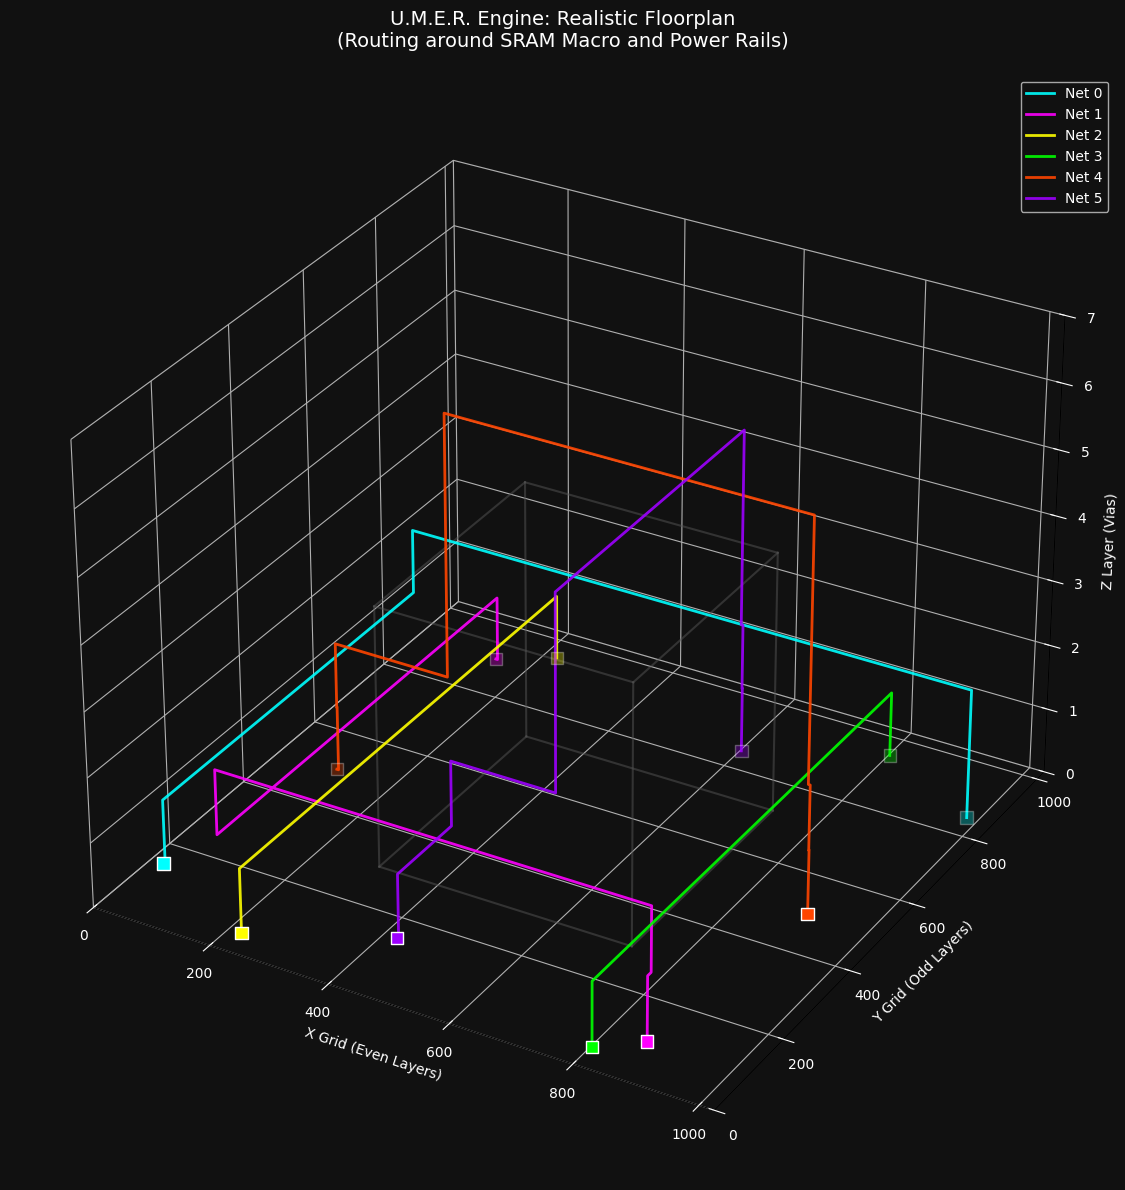

In [3]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time
import matplotlib.pyplot as plt

# ==============================================================================
#  THE U.M.E.R. ENGINE: REALISTIC VLSI FLOORPLAN STRESS TEST
#  Features: SRAM Macros, Power Rails, Standard Cell Alleys, RRR Negotiation
# ==============================================================================

CUDA_SOURCE = """
#define WIDTH 1024
#define HEIGHT 1024
#define LAYERS 8
#define TILE_SIZE 32
#define GRID_W 32 
#define ITERS 16  

#define IDX(x,y,z) ((z) * HEIGHT * WIDTH + (y) * WIDTH + (x))

// --- THE REALISTIC FLOORPLAN GENERATOR ---
__global__ void kernel_vlsi_seed(int* cost_map, int w, int h, int l) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= w || y >= h) return;

    for(int z=0; z<l; z++) {
        int idx = IDX(x,y,z);
        cost_map[idx] = 1; // Default: free space
        
        // 1. THE SRAM MACRO (Giant solid block in the center, Layers 0 to 4)
        if (z <= 4 && x >= 300 && x <= 724 && y >= 300 && y <= 724) {
            cost_map[idx] = 999999;
            continue; 
        }

        // 2. HORIZONTAL POWER RAILS (Layer 2 - blocks 10 pixels every 100)
        if (z == 2 && (y % 100 < 10)) {
            cost_map[idx] = 999999;
            continue;
        }

        // 3. VERTICAL POWER RAILS (Layer 3 - blocks 10 pixels every 100)
        if (z == 3 && (x % 100 < 10)) {
            cost_map[idx] = 999999;
            continue;
        }

        // 4. STANDARD CELL LOGIC (Layer 0 - Solid blocks with narrow vertical alleys)
        // Alleys are at x = 20-25, 40-45, 60-65, etc.
        if (z == 0 && (x % 20 > 5)) {
            cost_map[idx] = 999999;
        }
    }
}

__global__ void kernel_reset_for_net(int* grid, int* tile_active, int w, int h, int l, int src_x, int src_y, int src_z) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= w || y >= h) return;
    for(int z=0; z<l; z++) grid[IDX(x,y,z)] = -1; 
    if (x == src_x && y == src_y) {
        grid[IDX(src_x, src_y, src_z)] = 0; 
        tile_active[(src_y / TILE_SIZE) * GRID_W + (src_x / TILE_SIZE)] = 1;
    }
}

__global__ void kernel_route_strict(int* grid, int* cost_map, int* active_in, int* active_out, int w, int h, int l) {
    int bx = blockIdx.x, by = blockIdx.y;
    int tile_idx = by * GRID_W + bx;

    if (active_in[tile_idx] == 0) return;

    int tx = threadIdx.x, ty = threadIdx.y;
    int gx = bx * TILE_SIZE + tx, gy = by * TILE_SIZE + ty;
    
    int local_dist[LAYERS]; int local_cost[LAYERS];
    #pragma unroll
    for(int z=0; z<LAYERS; z++) {
        int idx = IDX(gx, gy, z);
        local_dist[z] = grid[idx]; local_cost[z] = cost_map[idx];
    }
    
    __shared__ int s_grid[LAYERS][TILE_SIZE][TILE_SIZE];
    #pragma unroll
    for(int z=0; z<LAYERS; z++) { s_grid[z][ty][tx] = local_dist[z]; }
    __syncthreads();

    bool changed = false;
    
    #pragma unroll
    for(int k=0; k<ITERS; k++) {
        for(int z=0; z<LAYERS; z++) {
            if (local_cost[z] > 900000) continue; 
            
            int best = s_grid[z][ty][tx];
            int current = (best == -1) ? 2000000 : best;

            if (z > 0) {
                int d = s_grid[z-1][ty][tx]; 
                if (d != -1 && d + 10 < current) current = d + 10;
            }
            if (z < LAYERS-1) {
                int u = s_grid[z+1][ty][tx]; 
                if (u != -1 && u + 10 < current) current = u + 10;
            }

            if (z % 2 != 0) { // Y-Axis
                int n;
                n = (ty > 0) ? s_grid[z][ty-1][tx] : ((gy > 0) ? grid[IDX(gx, gy-1, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
                n = (ty < TILE_SIZE-1) ? s_grid[z][ty+1][tx] : ((gy < h-1) ? grid[IDX(gx, gy+1, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
            }

            if (z % 2 == 0) { // X-Axis
                int n;
                n = (tx > 0) ? s_grid[z][ty][tx-1] : ((gx > 0) ? grid[IDX(gx-1, gy, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
                n = (tx < TILE_SIZE-1) ? s_grid[z][ty][tx+1] : ((gx < w-1) ? grid[IDX(gx+1, gy, z)] : -1);
                if (n != -1 && n + 1 < current) current = n + 1;
            }
            
            if (current != 2000000 && current != best) {
                s_grid[z][ty][tx] = current; changed = true;
            }
        }
        __syncthreads();
    }
    
    if (changed) {
        active_out[tile_idx] = 1;
        if (tx == TILE_SIZE-1 && bx < gridDim.x-1) active_out[tile_idx + 1] = 1;
        if (tx == 0 && bx > 0) active_out[tile_idx - 1] = 1;
        if (ty == TILE_SIZE-1 && by < gridDim.y-1) active_out[tile_idx + gridDim.x] = 1;
        if (ty == 0 && by > 0) active_out[tile_idx - gridDim.x] = 1;

        #pragma unroll
        for(int z=0; z<LAYERS; z++) {
            if (s_grid[z][ty][tx] != local_dist[z]) { grid[IDX(gx, gy, z)] = s_grid[z][ty][tx]; }
        }
    }
}
"""

def IDX(x, y, z, w, h): return z * w * h + y * w + x

def extract_path_strict(grid_host, w, h, l, start, target):
    cx, cy, cz = target
    path = [(cx, cy, cz)]
    current_cost = grid_host[IDX(cx, cy, cz, w, h)]
    
    if current_cost == -1 or current_cost > 900000: return []
        
    while (cx, cy, cz) != start:
        found = False
        if cz > 0 and grid_host[IDX(cx, cy, cz-1, w, h)] == current_cost - 10:
            cz -= 1; current_cost -= 10; found = True
        elif cz < l-1 and grid_host[IDX(cx, cy, cz+1, w, h)] == current_cost - 10:
            cz += 1; current_cost -= 10; found = True
        elif cz % 2 != 0 and not found:
            if cy > 0 and grid_host[IDX(cx, cy-1, cz, w, h)] == current_cost - 1:
                cy -= 1; current_cost -= 1; found = True
            elif cy < h-1 and grid_host[IDX(cx, cy+1, cz, w, h)] == current_cost - 1:
                cy += 1; current_cost -= 1; found = True
        elif cz % 2 == 0 and not found:
            if cx > 0 and grid_host[IDX(cx-1, cy, cz, w, h)] == current_cost - 1:
                cx -= 1; current_cost -= 1; found = True
            elif cx < w-1 and grid_host[IDX(cx+1, cy, cz, w, h)] == current_cost - 1:
                cx += 1; current_cost -= 1; found = True
                
        if not found: return [] 
        path.append((cx, cy, cz))
    return path

def run_realistic_floorplan():
    WIDTH, HEIGHT, LAYERS = 1024, 1024, 8
    N_NODES = WIDTH * HEIGHT * LAYERS
    N_TILES = (WIDTH // 32) * (HEIGHT // 32) 

    print("="*60)
    print("   U.M.E.R. ENGINE: REALISTIC FLOORPLAN STRESS TEST")
    print("="*60)

    mod = SourceModule(CUDA_SOURCE, options=["-O3"])
    k_seed = mod.get_function("kernel_vlsi_seed")
    k_reset = mod.get_function("kernel_reset_for_net")
    k_route = mod.get_function("kernel_route_strict")

    d_grid = cuda.mem_alloc(N_NODES*4)
    d_cost = cuda.mem_alloc(N_NODES*4)
    d_act_A = cuda.mem_alloc(N_TILES*4)
    d_act_B = cuda.mem_alloc(N_TILES*4)
    
    print("[1/3] Etching Realistic Chip (SRAM Macro, Power Rails, Alleys)...")
    k_seed(d_cost, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), block=(32,32,1), grid=(WIDTH//32, HEIGHT//32))
    base_cost_host = np.zeros(N_NODES, dtype=np.int32)
    cuda.memcpy_dtoh(base_cost_host, d_cost)
    grid_host = np.zeros(N_NODES, dtype=np.int32)

    # Carefully curated pins that exist cleanly inside the 5-pixel Layer 0 alleys
    nets = [
        ((22, 150, 0), (982, 850, 0)),  # Cross-chip diagonal
        ((142, 900, 0), (862, 100, 0)), # Opposite diagonal
        ((222, 50,  0), (222, 950, 0)), # Straight up the left flank
        ((802, 50,  0), (802, 950, 0)), # Straight up the right flank
        ((102, 500, 0), (902, 500, 0)), # Straight across the middle (Must go OVER or AROUND Macro)
        ((422, 150, 0), (602, 850, 0)), # Piercing close to the Macro
    ]

    unrouted_queue = list(range(len(nets)))
    routed_paths = {} 
    colors = ['#00FFFF', '#FF00FF', '#FFFF00', '#00FF00', '#FF4500', '#9D00FF']

    print("[2/3] Routing Complex Nets with RRR...\n")
    t0 = time.time()
    iteration = 0

    while unrouted_queue and iteration < 30:
        iteration += 1
        curr_net = unrouted_queue.pop(0)
        start, target = nets[curr_net]

        current_cost = base_cost_host.copy()
        for r_path in routed_paths.values():
            for px, py, pz in r_path:
                current_cost[IDX(px, py, pz, WIDTH, HEIGHT)] = 999999
        
        cuda.memcpy_htod(d_cost, current_cost)
        cuda.memset_d32(d_act_A, 0, N_TILES)
        k_reset(d_grid, d_act_A, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), np.int32(start[0]), np.int32(start[1]), np.int32(start[2]), block=(32,32,1), grid=(WIDTH//32, HEIGHT//32))
        
        stream = cuda.Stream()
        act_in, act_out = d_act_A, d_act_B
        for _ in range(150): # Extra iterations for complex detours
            cuda.memset_d32_async(act_out, 0, N_TILES, stream=stream)
            k_route(d_grid, d_cost, act_in, act_out, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), block=(32, 32, 1), grid=(WIDTH//32, HEIGHT//32), stream=stream)
            act_in, act_out = act_out, act_in
        stream.synchronize()
        
        cuda.memcpy_dtoh(grid_host, d_grid)
        path = extract_path_strict(grid_host, WIDTH, HEIGHT, LAYERS, start, target)

        if path:
            print(f"   Iter {iteration:02d} | Net {curr_net}: 🟢 ROUTED ({len(path)} segments)")
            routed_paths[curr_net] = path
        else:
            print(f"   Iter {iteration:02d} | Net {curr_net}: 🔴 BLOCKED! Triggering RRR...")
            cuda.memcpy_htod(d_cost, base_cost_host)
            cuda.memset_d32(d_act_A, 0, N_TILES)
            k_reset(d_grid, d_act_A, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), np.int32(start[0]), np.int32(start[1]), np.int32(start[2]), block=(32,32,1), grid=(WIDTH//32, HEIGHT//32))
            
            act_in, act_out = d_act_A, d_act_B
            for _ in range(150): 
                cuda.memset_d32_async(act_out, 0, N_TILES, stream=stream)
                k_route(d_grid, d_cost, act_in, act_out, np.int32(WIDTH), np.int32(HEIGHT), np.int32(LAYERS), block=(32, 32, 1), grid=(WIDTH//32, HEIGHT//32), stream=stream)
                act_in, act_out = act_out, act_in
            stream.synchronize()
            
            cuda.memcpy_dtoh(grid_host, d_grid)
            ghost_path = extract_path_strict(grid_host, WIDTH, HEIGHT, LAYERS, start, target)

            if not ghost_path:
                print(f"        > FATAL: Net {curr_net} blocked by base chip hardware. Cannot route.")
                continue

            ghost_nodes = set(ghost_path)
            victims = []
            for r_net, r_path in list(routed_paths.items()):
                if set(r_path).intersection(ghost_nodes):
                    victims.append(r_net)
                    del routed_paths[r_net] 
                    unrouted_queue.append(r_net)
            
            print(f"        > RIPPED UP Nets {victims} to make room.")
            routed_paths[curr_net] = ghost_path

    total_time = (time.time() - t0) * 1000
    print("\n" + "-" * 60)
    print(f"   ► TOTAL ROUTING TIME:  {total_time:.2f} ms")
    print(f"   ► SUCCESS RATE:        {len(routed_paths)} / {len(nets)} Nets")
    print("-" * 60)

    print("[3/3] Generating Matplotlib 3D Visualization...")
    fig = plt.figure(figsize=(14, 12))
    ax = fig.add_subplot(111, projection='3d')

    # Draw the SRAM Macro Block as a semi-transparent gray cube
    import itertools
    r = [300, 724]
    for s, e in itertools.combinations(np.array(list(itertools.product(r, r, [0, 4]))), 2):
        if np.sum(np.abs(s-e)) == r[1]-r[0] or np.sum(np.abs(s-e)) == 4:
            ax.plot3D(*zip(s, e), color='#555555', linewidth=1.5, alpha=0.5)

    for net_id, path in routed_paths.items():
        x, y, z = zip(*path)
        color = colors[net_id % len(colors)]
        ax.plot(x, y, z, color=color, linewidth=2, alpha=0.9, label=f'Net {net_id}')
        # Make the pins distinctly visible
        ax.scatter([x[0], x[-1]], [y[0], y[-1]], [z[0], z[-1]], color=color, s=80, marker='s', edgecolors='white', linewidth=1)

    ax.set_title("U.M.E.R. Engine: Realistic Floorplan\n(Routing around SRAM Macro and Power Rails)", color='white', pad=20, size=14)
    ax.set_xlabel('X Grid (Even Layers)')
    ax.set_ylabel('Y Grid (Odd Layers)')
    ax.set_zlabel('Z Layer (Vias)')
    ax.set_xlim(0, WIDTH); ax.set_ylim(0, HEIGHT); ax.set_zlim(0, LAYERS - 1)

    fig.patch.set_facecolor('#111111'); ax.set_facecolor('#111111')
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.label.set_color('white')
        axis.set_tick_params(colors='white')
        axis.pane.fill = False; axis.pane.set_edgecolor('#333333')

    plt.legend(facecolor='#111111', labelcolor='white', loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_realistic_floorplan()